In [75]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
a=pd.read_excel("aiml exp6 dataset.xlsx")
a.head(4)

,month,load(Mw),class
0,4,40,no
1,6,50,no
2,7,80,no
3,10,100,no


In [77]:
a['class']=a['class'].map({'no':0,'yes':1})
print(a)

   month  load(Mw)  class
0      4        40      0
1      6        50      0
2      7        80      0
3     10       100      0
4     12       120      0
5     16       140      0
6     20       300      1
7     22       340      1
8     24       380      1


In [81]:
X=a[['month','load(Mw)']]
y=a['class']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33,random_state=42)
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(max_depth=2, random_state=0)
clf.fit(X_train, y_train.values.ravel())
y_pred = clf.predict (X_test)
y_pred

array([1, 0, 0])

In [83]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
print("accuracy score",accuracy_score(y_test, y_pred))
print("mean_squared_error",mean_squared_error(y_test, y_pred))
from sklearn.metrics import confusion_matrix

accuracy score 1.0
mean_squared_error 0.0


In [85]:
y_true=y_test
data=confusion_matrix(y_true,y_pred)
data

array([[2, 0],
       [0, 1]])

<Axes: xlabel='Predicted', ylabel='Actual'>

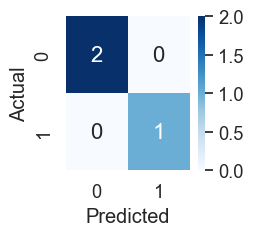

In [87]:
import seaborn as sn
df_cm = pd.DataFrame(data, columns=np.unique(y_true), index =np.unique(y_true))
df_cm.index.name = "Actual"
df_cm.columns.name = "Predicted"
plt.figure(figsize = (2,2))
sn.set(font_scale=1.2)
df_cm
sn.heatmap(df_cm, cmap="Blues", annot=True,annot_kws= {"size":16})

In [91]:
new_month=20
new_load=120
new_pred=clf.predict([[new_month,new_load]])
print(new_pred[0])


0
